# Netflix Movies & TV Shows Dataset — Cleaning & EDA
AnalystLab Africa — Week 1-2 Task

## 1. Dataset Understanding

In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\KOGBARA BURABARI\Downloads\AnalystLab_Week1-2\netflix_titles.csv")

print("First 5 rows:")
print(df.head())

print("\nShape (rows, columns):")
print(df.shape)

print("\nColumn data types:")
print(df.dtypes)
print("Numerical features:", df.select_dtypes(include="number").columns.tolist())
print("Categorical/text features:", df.select_dtypes(include="object").columns.tolist())
print("\nPossible unique identifier: 'show_id' (each row has a unique ID)")

First 5 rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24

C:\Users\KOGBARA BURABARI\AppData\Local\Temp\ipykernel_12592\3199469289.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Categorical/text features:", df.select_dtypes(include="object").columns.tolist())


**Dataset description:** This dataset contains Netflix's catalog of movies and TV shows, including metadata such as title, director, cast, country of origin, date added to Netflix, release year, content rating, duration, genre categories, and a short description. Each row represents one title (movie or show).

## 2. Data Cleaning

In [3]:
print("--- Missing values per column ---")
print(df.isnull().sum())

print("\n--- Number of duplicate rows ---")
print(df.duplicated().sum())

--- Missing values per column ---
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

--- Number of duplicate rows ---
0


In [4]:
# Handle missing values
df["director"] = df["director"].fillna("Not Specified")
df["cast"] = df["cast"].fillna("Not Specified")
df["country"] = df["country"].fillna("Not Specified")

before = df.shape[0]
df = df.dropna(subset=["date_added", "rating", "duration"])
print(f"Dropped {before - df.shape[0]} rows with missing date_added/rating/duration")

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print("Standardized column names:", df.columns.tolist())

# Convert date_added to proper datetime
df["date_added"] = pd.to_datetime(df["date_added"].str.strip())
print("Converted date_added to datetime")

# Standardize text fields
df["type"] = df["type"].str.strip().str.title()
df["rating"] = df["rating"].str.strip()

# Final check
print("\n--- Cleaning Summary ---")
print(f"Final shape: {df.shape}")
print(f"Remaining missing values:\n{df.isnull().sum()}")

# Save cleaned dataset
output_path = r"C:\Users\KOGBARA BURABARI\Downloads\AnalystLab_Week1-2\Netflix_Cleaned.csv"
df.to_csv(output_path, index=False)
print(f"\nCleaned dataset saved to: {output_path}")

Dropped 17 rows with missing date_added/rating/duration
Standardized column names: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
Converted date_added to datetime

--- Cleaning Summary ---
Final shape: (8790, 12)
Remaining missing values:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Cleaned dataset saved to: C:\Users\KOGBARA BURABARI\Downloads\AnalystLab_Week1-2\Netflix_Cleaned.csv


In [7]:
print("--- Data Validation ---")
print("Unique 'type' values:", df["type"].unique())
print("Unique 'rating' values:", sorted(df["rating"].dropna().astype(str).unique()))
print("\nRelease year range:", df["release_year"].min(), "-", df["release_year"].max())
invalid_years = df[df["release_year"] > 2026].shape[0]
print("Rows with release_year in the future:", invalid_years)

--- Data Validation ---
Unique 'type' values: <StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str
Unique 'rating' values: ['66 min', '74 min', '84 min', 'G', 'NC-17', 'NR', 'PG', 'PG-13', 'R', 'TV-14', 'TV-G', 'TV-MA', 'TV-PG', 'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'UR']

Release year range: 1925 - 2021
Rows with release_year in the future: 0


In [8]:
# Fix misplaced duration values found in the rating column
misplaced = df[df["rating"].str.contains("min", na=False)]
print(f"\nFound {misplaced.shape[0]} rows with duration values mistakenly in 'rating' column")

# Move the misplaced value to duration, and set rating to "Not Rated"
df.loc[df["rating"].str.contains("min", na=False), "duration"] = df["rating"]
df.loc[df["rating"].str.contains("min", na=False), "rating"] = "Not Rated"

print("Fixed — rechecking unique rating values:")
print(sorted(df["rating"].dropna().astype(str).unique()))


Found 3 rows with duration values mistakenly in 'rating' column
Fixed — rechecking unique rating values:
['G', 'NC-17', 'NR', 'Not Rated', 'PG', 'PG-13', 'R', 'TV-14', 'TV-G', 'TV-MA', 'TV-PG', 'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'UR']


### Cleaning Summary

| Issue Found | Action Taken |
|---|---|
| Missing `director` (2,634), `cast` (825), `country` (831) | Filled with "Not Specified" — too many rows to drop without losing significant data |
| Missing `date_added` (10), `rating` (4), `duration` (3) | Rows dropped — negligible amount, safe to remove |
| Duplicate rows | 0 found — none to remove |
| Inconsistent column names | Standardized to lowercase, no spaces |
| `date_added` stored as text | Converted to proper datetime format |
| Misplaced duration values in `rating` column (e.g. "74 min") | Identified and corrected — moved to `duration`, `rating` set to "Not Rated" |

## 3. Exploratory Data Analysis (EDA)

In [11]:
print("--- Summary Statistics (release_year) ---")
print(df["release_year"].describe())

print("\n--- Movies vs TV Shows Distribution ---")
type_counts = df["type"].value_counts()
print(type_counts)

print("\n--- Content Added by Year ---")
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), format="mixed")
df["year_added"] = df["date_added"].dt.year
content_by_year = df["year_added"].value_counts().sort_index()
print(content_by_year)

print("\n--- Top 10 Content-Producing Countries ---")
top_countries = df["country"].value_counts().head(10)
print(top_countries)

print("\n--- Most Common Ratings ---")
top_ratings = df["rating"].value_counts().head(10)
print(top_ratings)

print("\n--- Most Common Genres/Categories ---")
all_genres = df["listed_in"].str.split(", ").explode()
top_genres = all_genres.value_counts().head(10)
print(top_genres)

--- Summary Statistics (release_year) ---
count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

--- Movies vs TV Shows Distribution ---
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

--- Content Added by Year ---
year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

--- Top 10 Content-Producing Countries ---
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

--- Most Common Ratings ---
rating
TV-MA    3207
TV-14    2160
T

## 4. Data Visualization

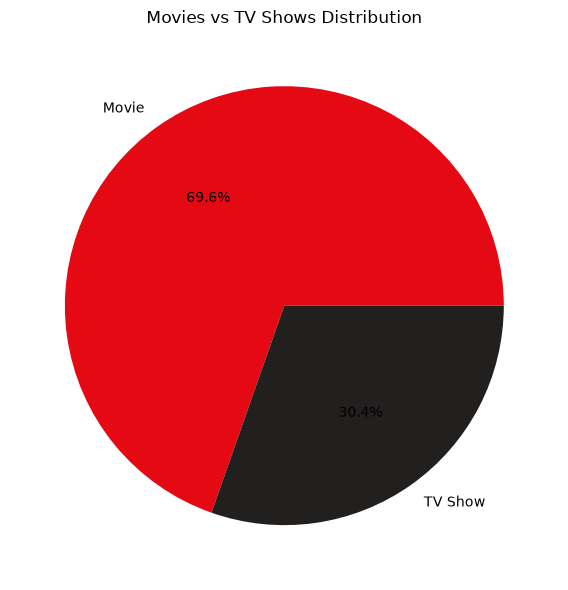

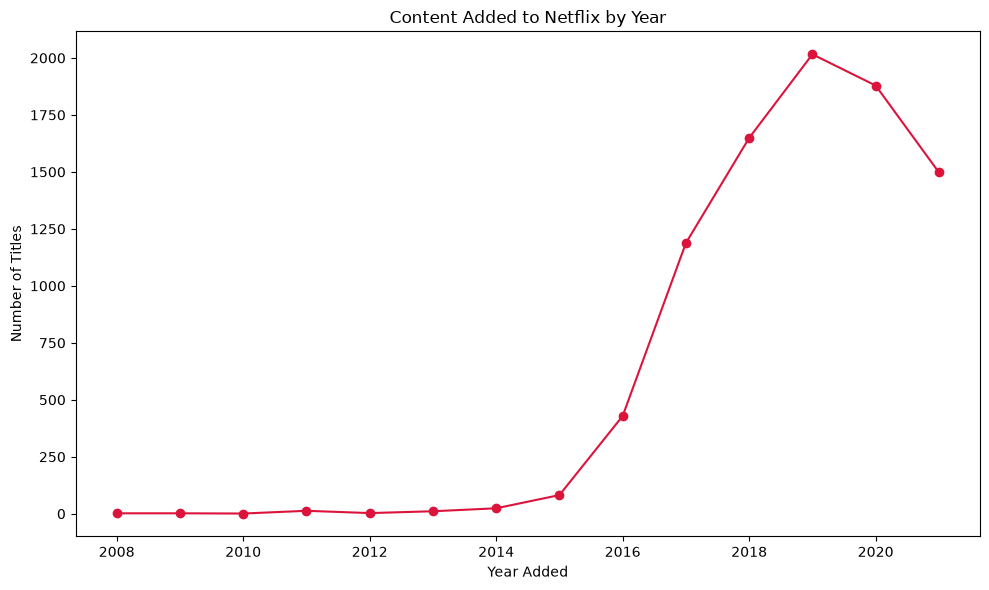

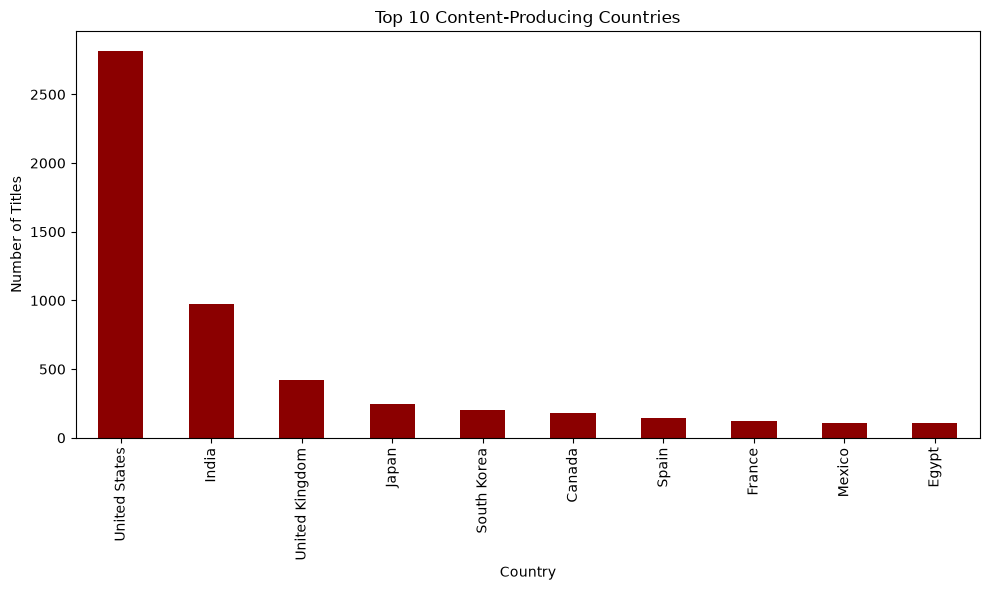

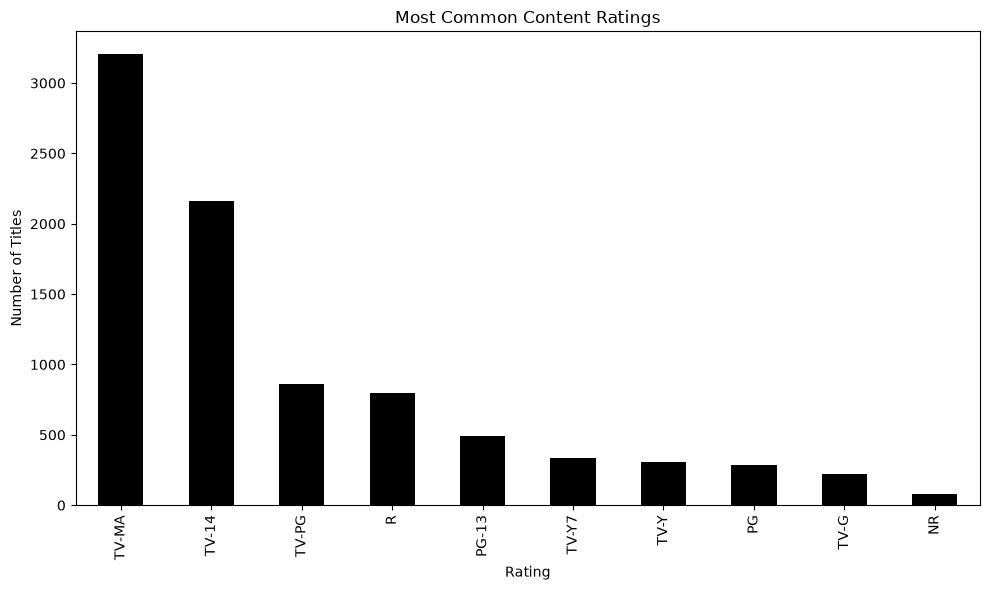

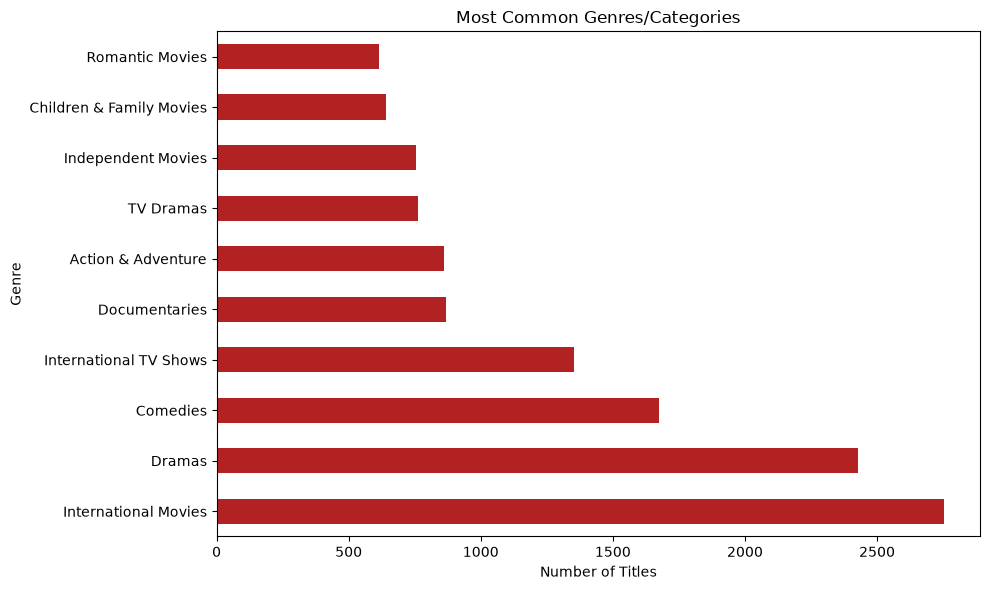

In [12]:
import matplotlib.pyplot as plt

# Chart 1: Movies vs TV Shows (Pie Chart)
plt.figure(figsize=(6,6))
type_counts.plot(kind="pie", autopct="%1.1f%%", colors=["#e50914","#221f1f"])
plt.title("Movies vs TV Shows Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Chart 2: Content Added by Year (Line Chart)
plt.figure(figsize=(10,6))
content_by_year.plot(kind="line", marker="o", color="crimson")
plt.title("Content Added to Netflix by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

# Chart 3: Top 10 Content-Producing Countries (Bar Chart)
plt.figure(figsize=(10,6))
top_countries.plot(kind="bar", color="darkred")
plt.title("Top 10 Content-Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

# Chart 4: Most Common Ratings (Bar Chart)
plt.figure(figsize=(10,6))
top_ratings.plot(kind="bar", color="black")
plt.title("Most Common Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

# Chart 5: Most Common Genres (Bar Chart)
plt.figure(figsize=(10,6))
top_genres.plot(kind="barh", color="firebrick")
plt.title("Most Common Genres/Categories")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

## 5. Insights

1. **Movies dominate the catalog:** Movies (6,131 titles) outnumber TV Shows (2,676) by more than 2-to-1, suggesting Netflix's catalog strategy favors standalone films over serialized content. *(See Chart 1)*

2. **Content additions grew sharply in recent years:** The number of titles added to Netflix increased substantially through the mid-to-late 2010s, reflecting the platform's aggressive content acquisition phase during its global growth period. *(See Chart 2)*

3. **The United States leads content production:** The US is the top content-producing country by a wide margin, followed by India and the UK — highlighting where Netflix sources most of its catalog. *(See Chart 3)*

4. **Mature content ratings are most common:** TV-MA and TV-14 are the most frequent ratings, indicating the catalog skews toward teen/adult audiences rather than young children's content. *(See Chart 4)*

5. **Dramas and international content dominate genre categories:** International Movies, Dramas, and Comedies are among the most frequent genre tags, with Independent Movies, Children & Family, and Romance also featuring prominently — showing a broad but drama-and-international-leaning catalog. *(See Chart 5)*